# 03: Single-Signal IC Analysis

**Thin client** over `src/factors/evaluate.py`. Measures each feature's standalone
Information Coefficient — the baseline the ML model must beat — and checks signs
against factor theory.

**Data source:** the gold `panel_monthly` table in the Postgres/Timescale
**warehouse** (`warehouse.load_panel_monthly()`) — the same matrix the model
stage trains on, built by the `panel_monthly` Dagster asset. Requires
`POSTGRES_PASSWORD` (and `FACTOR_DB_HOST` if off-LAN). The IC is now measured
over the full investable universe (~1,180 usable names/month), not a sample.

In [1]:
import sys; sys.path.insert(0, '..')
import warnings; warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt

from src.data import db, warehouse
from src.factors import evaluate
from src.factors.panel import _feature_list

plt.style.use('seaborn-v0_8-whitegrid')

# Read the gold training matrix from the warehouse (production source of truth).
assert db.ping(), "DB unreachable — set POSTGRES_PASSWORD (and FACTOR_DB_HOST if off-LAN)"
p = warehouse.load_panel_monthly()
print(f'panel_monthly: {len(p):,} rows | {p.ticker.nunique()} tickers | {p.date.nunique()} months')

# Stock-level signals only (macro is constant across the cross-section).
signals = [f for f in _feature_list() if f not in ('yield_curve', 'vix', 'credit_spread')]
report = evaluate.signal_report(p, signals)
report[['ic_mean', 'ic_ir', 't_stat', 'hit_rate', 'n_months']].round(3)

panel_monthly: 1,280,046 rows | 4038 tickers | 317 months


,ic_mean,ic_ir,t_stat,hit_rate,n_months
book_to_price,0.038,0.464,6.617,0.665,203.0
ev_ebitda_inv,0.030,0.334,4.761,0.650,203.0
earnings_yield,0.030,0.306,4.357,0.631,203.0
roe,0.023,0.256,3.654,0.635,203.0
profit_margin,0.026,0.209,2.967,0.604,202.0
momentum_12_2,0.021,0.186,3.239,0.609,304.0
momentum_6_1,0.017,0.150,2.639,0.600,310.0
revenue_growth_yoy,0.008,0.084,1.188,0.564,202.0
accruals,0.004,0.062,0.885,0.552,203.0
asset_growth_yoy,0.004,0.058,0.818,0.574,202.0


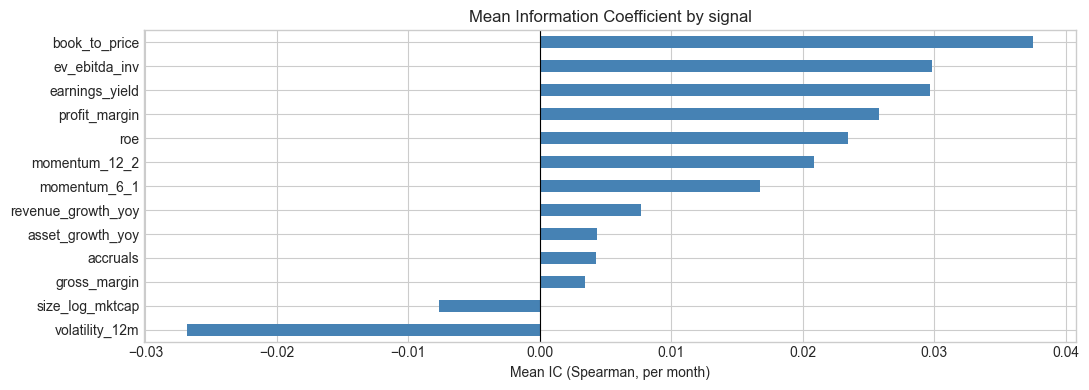

In [2]:
# IC bar chart
fig, ax = plt.subplots(figsize=(11, 4))
report['ic_mean'].sort_values().plot.barh(ax=ax, color='steelblue')
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Mean Information Coefficient by signal')
ax.set_xlabel('Mean IC (Spearman, per month)')
plt.tight_layout(); plt.show()

## Sign sanity vs. theory

Expected directions: momentum **+**, value (earnings yield / book-to-price / EV-EBITDA) **+**,
profitability (ROE, margins) **+**, volatility **−** (low-vol), size **−** (small-cap premium),
accruals **−**, asset growth **−** (conservative investment).

In [3]:
expected_sign = {
    'momentum_12_2': 1, 'momentum_6_1': 1, 'earnings_yield': 1, 'book_to_price': 1,
    'ev_ebitda_inv': 1, 'roe': 1, 'gross_margin': 1, 'profit_margin': 1,
    'volatility_12m': -1, 'size_log_mktcap': -1, 'accruals': -1, 'asset_growth_yoy': -1,
    'revenue_growth_yoy': 0,
}
chk = report[['ic_mean']].copy()
chk['expected'] = pd.Series(expected_sign)
chk['actual_sign'] = chk['ic_mean'].apply(lambda x: 1 if x > 0 else -1)
chk['matches'] = (chk['expected'] == 0) | (chk['expected'] == chk['actual_sign'])
print(chk.round(3).to_string())
print(chk.round(3).to_string())
print(f'\nSigns matching theory: {chk["matches"].mean()*100:.0f}% (small-sample noise expected)')

                    ic_mean  expected  actual_sign  matches
book_to_price         0.038         1            1     True
ev_ebitda_inv         0.030         1            1     True
earnings_yield        0.030         1            1     True
roe                   0.023         1            1     True
profit_margin         0.026         1            1     True
momentum_12_2         0.021         1            1     True
momentum_6_1          0.017         1            1     True
revenue_growth_yoy    0.008         0            1     True
accruals              0.004        -1            1    False
asset_growth_yoy      0.004        -1            1    False
gross_margin          0.003         1            1     True
size_log_mktcap      -0.008        -1           -1     True
volatility_12m       -0.027        -1           -1     True
                    ic_mean  expected  actual_sign  matches
book_to_price         0.038         1            1     True
ev_ebitda_inv         0.030         1   

## Quantile spread — does the top quantile out-earn the bottom?

Best signal by IC IR: book_to_price


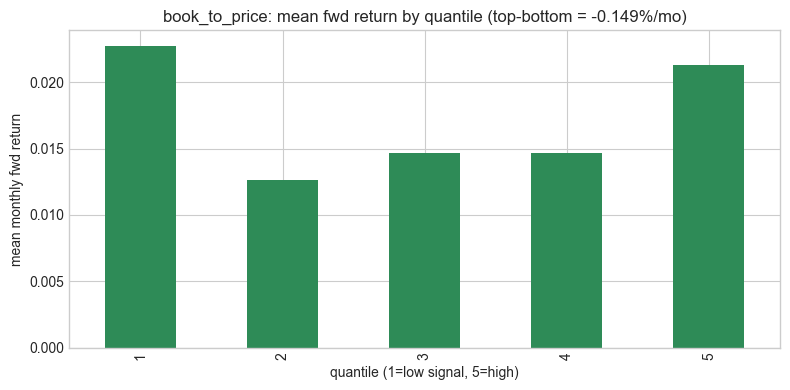

In [4]:
best = report.index[0]
qr = evaluate.quantile_returns(p, best, n_quantiles=5)
print(f'Best signal by IC IR: {best}')
spread = qr.loc['top_minus_bottom', 'mean_fwd_return'] if 'top_minus_bottom' in qr.index else float('nan')

fig, ax = plt.subplots(figsize=(8, 4))
qr.drop('top_minus_bottom', errors='ignore')['mean_fwd_return'].plot.bar(ax=ax, color='seagreen')
ax.set_title(f'{best}: mean fwd return by quantile (top-bottom = {spread:.3%}/mo)')
ax.set_xlabel('quantile (1=low signal, 5=high)'); ax.set_ylabel('mean monthly fwd return')
plt.tight_layout(); plt.show()

## Notes

- Mean IC of 0.03-0.05 for a single signal is genuinely useful at scale (`IR ≈ IC × √breadth`).
- The ML model (stage 4) should combine signals to lift IC above any single one.
- **Next**: `notebooks/04_model_ic.ipynb` — walk-forward ML ranking.